# Earnings Return Prediction Challenge - Starter Template (v7 20240419)

In this project we will train a model to predict the stock return on the day of earnings for US companies. This template contains code to get you started with the project.

## Standard imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Notebook configuration
- Please set the **<span style="color:red">config['enddate']</span>** to the most recent Friday. Do not change any other config parameters. 

- The environment might take around one minute to load
- The  **Operators** are functions that can be used to apply a series of transformations to a data variable or alpha.
> [Introduction to Operators](https://trexsim.com/trexsim/pysim/tutorial2022/operators.html)
> 
> Find all available  operators in the [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html)

In [3]:
import operators as op              # find all available operators, https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html
import utilities as utils
import strategy_utilities as sutil
from strategy_research import load_env

config = {
    'enddate': 20241122,            # Please setting the config['enddate'] to the most recent Friday.
    'region': 'USA',
    'universe': 'top3000',
    'delay': 0,
    'booksize':1e6,
    'refit_interval': 'OneQuarter',
    'filter_function_uuid': 'none',
    'fit_function_uuid': 'none',
    'pp_function_uuid': 'none',
    'tf_function_uuid': 'none',
    'postalpha': False,
    'compress': False,    
    'load_cache': False,
    'save_cache': False,
    'skip_post_strategy': True,
    'skip_test_cases': True,
    'strat_dir': './'
}

def tf_function(preA, data): return preA
function_dict = {'tf_function': tf_function}

env = load_env('USA')
data = sutil.create_strategy_data(function_dict, config, 'full', env, use_pre_compressed=True)
data = sutil.add_builtin_functions(data, function_dict, config, env)

Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20241122.raw.mat
Variable numstocks is loaded from /home/newprod/production/data/USA/simvars/numstocks/numstocks.20241122.raw.mat
Variable dates is loaded from /home/newprod/production/data/USA/simvars/dates/dates.20241122.raw.mat
Variable dates is loaded from /home/newprod/production/data/USA/simvars/dates/dates.20241122.adj_amend.mat 4756
Variable numdates is loaded from /home/newprod/production/data/USA/simvars/numdates/numdates.20241122.adj_amend.mat 4756
Variable startdate is loaded from /home/newprod/production/data/USA/simvars/startdate/startdate.20241122.adj_amend.mat 4756
Variable enddate is loaded from /home/newprod/production/data/USA/simvars/enddate/enddate.20241122.adj_amend.mat 4756
Variable spread_timeweighted_allday is loaded from /home/newprod/production/data/USA/simvars/spread_timeweighted_allday/spread_timeweighted_allday.20241122.adj_amend.ci 4756
Variable numstocks is loade

In [46]:
np.nansum(data['load_simvar_hhmm']('mktcap')[:,3900])

0.0

## **Mask**

Most data variables at Trexquant are 2D matrices with dimensions _num\_stocks_ x _num\_dates_. We want to filter on the dates when earnings were announced and convert the 2D matrix to a vector so that it can be used in an ML model.

To find the earnings date we use the data variable [trading_days_til_next_ann](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/trading_days_til_next_ann/). We also require the time of announcement which we get from the data variable [fs_next_ann_time](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/fs_next_ann_time/). We use the following logic to construct the mask:
1. If the annoucement time is before the trading time (1500), set the earnings return day as today.
2. If the annoucement time is after the trading time (1500), set the earnings return day as the next day.

The code in the cell below constructs the mask

In [4]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

# contruct earning mask based on trading_days_til_next_ann
valid_mask = (data['load_simvar_hhmm']('trading_days_til_next_ann') == 1)
fs_next_ann_time = data['load_simvar_hhmm']('fs_next_ann_time')

# based on trading_days_til_next_ann and fs_next_ann_time
# delay one day if earnings is announced after we trade
valid_effect_mask = np.zeros_like(valid_mask, dtype=np.float32)
for si, di in zip(*np.where((valid_mask == 1) & (data['valids']))):

    # skip if we are unable to get the target
    if di + data['delay'] >= data['numdates']:
        continue

    time = fs_next_ann_time[si, di]

    if time <= 1500:
        target_di = di
        target_last_di = di-1
    elif time > 1500 and di + 1 < data['numdates']:
        target_di = di+1
        target_last_di = di
    if valid_effect_mask[si, target_di] != 1:
        valid_effect_mask[si, target_di] = 1
    if valid_effect_mask[si, target_last_di] != 1:
        valid_effect_mask[si, target_last_di] = 1
        
bet_days_mask = valid_effect_mask==1
bet_days_mask = op.at_nan2zero(bet_days_mask*1.0)
flatten_mask = (bet_days_mask==1.0)

In [23]:
data['load_simvar_hhmm']('mktcap')

array([[nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]], dtype=float32)

In [32]:
mktcaprank_1d = op.at_nan2zero(op.cs_rank(data['load_simvar_hhmm']('mktcap')[:, 3000]))
top70_1d = (mktcaprank_1d > 1.7)
med37_1d = ((mktcaprank_1d <= 1.7) & (mktcaprank_1d > 1.3))
bot30_1d = (mktcaprank_1d <= 1.3)
regime_X = np.stack((top70_1d, med37_1d, bot30_1d), axis=-1)

In [35]:
pd.DataFrame(regime_X).describe()

,0,1,2
count,11509,11509,11509
unique,2,2,2
top,False,False,True
freq,10229,9815,8535


## **Target**

For this challenge we will use one-day forward ret1_excess as the target
- target columns: `target`, which is the forward [ret1_excess](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/ret1_excess/)
- dates: `dates` column is the masked dates, which is the day we want to enter our position before the earning announcement.
- stock index: `si`
- date index: `di`
- `[si,di]` data point indicates that we want to enter into the position for the stock at si th index and di th date just before the company announces its results

In [87]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###

ret1_excess = data['load_simvar_hhmm']('ret1_excess')
fwd_ret = op.ts_delay((ret1_excess),-1) # one day forward ret1_excess

# modify mask to remove points where target is invalid
flatten_mask[np.isnan(fwd_ret)] = False  
target = fwd_ret[flatten_mask]

# put target into the dataframe
df = pd.DataFrame()
df['target'] = target

num_of_stocks, num_of_dates = ret1_excess.shape
si_list = np.array([list(np.arange(num_of_stocks))]*num_of_dates).transpose()
di_list = np.array([list(np.arange(num_of_dates))]*num_of_stocks)

df['si'] = si_list[flatten_mask]
df['di'] = di_list[flatten_mask]
dates_mat = np.tile(data['dates'], (num_of_stocks,1))
df['dates'] = dates_mat[flatten_mask]

## **Features**

For this challenge you can use any of the data variables available in the [data description](https://trexsim.com/trexsim/pysim/data_description/USA/).
You may further apply any transformations to the data variables that you deem appropriate.

Please keep in mind that **all features used must be dimensionless**. Features that have dimensions of price of number of shares are subject to adjustment which introduces a forward bias. An easy way to check if a data variable is subject to adjustment is to check if there is anything in the `adjfactor_type` column in the data description.
Features which are subject to adjustment can be normalized using operators like `ts_zscore`, `ts_norm` and `ts_std_normalized`. Find all available operators in [operators list](https://www.trexsim.com/trexsim/pysim/comptutorial/operators.html).

You can combine existing features and apply operators to make new features as long as the transformations are reasonable.

In the followint cell, you will see 3 feature used in the benchmark model.
- [ret1](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/ret1/): On day return.
- [linkup_job_active_count](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/linkup_job_active_count/): number of active jobs.

In [10]:
import gc
gc.collect()

0

In [7]:
# from sklearn.preprocessing import QuantileTransformer
# transformer = QuantileTransformer(output_distribution='normal', random_state=42)

In [11]:
### ---- ---- ---- ---- Featurs used in the Benchmark model ---- ---- ---- ---- ###

####### feature 1: tsz_ret1
ret1 = data['load_simvar_hhmm']('ret1')                    # Load data variable
tsz_ret1 = op.at_nan2zero(op.ts_zscore(ret1, 21))          # Calculate the feature
df['tsz_ret1'] = tsz_ret1[flatten_mask]                    # Apply the mask to the feature and save it in the dataframe.

####### feature 2: tsz_ret1_delay1
tsz_ret1_d1 = op.at_nan2zero(op.ts_zscore(op.ts_delay(ret1,1), 21))       
df['tsz_ret1_d1'] = tsz_ret1_d1[flatten_mask] 

####### feature 3: linkup_job_active_count
linkup_job_active_count = data['load_simvar_hhmm']('linkup_job_active_count')
linkup_job_active_count = op.at_nan2zero(op.ts_zscore(op.ts_fill(linkup_job_active_count), 21))
df['linkup_job_active_count'] = linkup_job_active_count[flatten_mask]

# name of all features
features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates']]
print(f"Current features: {features_ls}")

Current features: ['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count']


#### **New Features**

Here is an example on adding a new technical feature to the model:

- [CloseSpread_vwap](https://www.trexsim.com/trexsim/pysim/data_description/variable/USA/CloseSpread_vwap/): close minus vwap divided by close



In [7]:
from tqdm import tqdm

In [8]:
# def calculate_markit_Milliq_distrib(revere_distrib, markit_Milliq):
#     numstocks, numdates = markit_Milliq.shape
#     markit_Milliq_distrib = np.zeros((numstocks, numdates))

#     for date_index in tqdm(range(numdates)):
#         sparse_matrix = revere_distrib[date_index].tocsc()  # 使用更适合列操作的格式

#         # 计算所有股票在该日期的markit_Milliq总和
#         sum_markit_Milliq = sparse_matrix.dot(markit_Milliq[:, date_index])

#         # 计算每个股票的相关股票数量（即True的数量）
#         count_related_stocks = sparse_matrix.getnnz(axis=1)

#         # 避免除以零，对于没有相关股票的情况，我们设为0或其他默认值
#         with np.errstate(divide='ignore', invalid='ignore'):
#             average_markit_Milliq = np.true_divide(sum_markit_Milliq, count_related_stocks)
#             average_markit_Milliq[~np.isfinite(average_markit_Milliq)] = 0  # 将无穷大和NaN值设为0

#         markit_Milliq_distrib[:, date_index] = average_markit_Milliq

#     return markit_Milliq_distrib

In [ ]:
revere_same_city,  fs_analyst_relation_20days, ms_analyst_relation_lb252, shared_events_trna_tag_analyst_raise

In [9]:
factset_shared_analyst_relationship_num_diffInd = data['load_simvar_hhmm']('factset_shared_analyst_relationship_num')
ret5_excess = data['load_simvar_hhmm']('ret5_excess')
def calculate_markit_Milliq_distrib(revere_distrib, markit_Milliq):
    numstocks, numdates = markit_Milliq.shape
    markit_Milliq_distrib = np.zeros((numstocks, numdates))


    for date_index in tqdm(range(numdates)):
        sparse_matrix = revere_distrib[date_index].tocsc()
        sum_markit_Milliq = sparse_matrix.dot(markit_Milliq[:, date_index])
        weight_indices = np.where(markit_Milliq[:, date_index]==0.0, 0.0, 1.0)
        count_related_stocks = sparse_matrix.dot(weight_indices)

        with np.errstate(divide='ignore', invalid='ignore'):
            average_markit_Milliq = np.true_divide(sum_markit_Milliq, count_related_stocks)
            average_markit_Milliq[~np.isfinite(average_markit_Milliq)] = 0
        markit_Milliq_distrib[:, date_index] = average_markit_Milliq
    return markit_Milliq_distrib


since_qua = data['load_simvar_hhmm']('days_since_first_trading_day_of_quarter')
since_ann = data['load_simvar_hhmm']('trading_days_since_last_ann')
ret5_excess_alreadyann = ((since_ann - since_qua) <= 0) * (ret5_excess)
coverageret5e = op.at_nan2zero(calculate_markit_Milliq_distrib(factset_shared_analyst_relationship_num_diffInd, np.nan_to_num(ret5_excess_alreadyann)))
df['coverageret5e'] = coverageret5e[flatten_mask]

KeyboardInterrupt: 

In [11]:

# revere_customer2supplier = data['load_simvar_hhmm']('revere_customer2supplier')
# revere_customer_sameSec = data['load_simvar_hhmm']('revere_customer_sameSec')
# revere_distrib = data['load_simvar_hhmm']('revere_distrib')
# revere_licenin_sameSec = data['load_simvar_hhmm']('revere_licenin_sameSec')
# revere_all_partner = data['load_simvar_hhmm']('revere_all_partner')
# revere_rescolb = data['load_simvar_hhmm']('revere_rescolb')
	

# # fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# # fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # fast_IS_EPS_zscore_c2s = calculate_markit_Milliq_distrib(revere_customer2supplier, fast_IS_EPS_zscore)
# # df['fast_IS_EPS_zscore_c2s'] = fast_IS_EPS_zscore_c2s[flatten_mask] # 0.78 0.90
# # print(sum(df['fast_IS_EPS_zscore_c2s'] !=0)) 

# # # revere_customer2supplier_avg_ret1 = data['load_simvar_hhmm']('revere_customer2supplier_avg_ret1')
# # # revere_customer2supplier_avg_ret1_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_mean(revere_customer2supplier_avg_ret1, 30))))
# # # df['revere_customer2supplier_avg_ret1_zscore'] = revere_customer2supplier_avg_ret1_zscore[flatten_mask]

# # ret20 = data['load_simvar_hhmm']('ret20')
# # ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_zscore(ret20, 25))))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # ret20_tzscore_c2s = calculate_markit_Milliq_distrib(revere_customer2supplier, ret20_tzscore)
# # df['ret20_tzscore_c2s'] = ret20_tzscore_c2s[flatten_mask] # 0.84 0.92




# # fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# # fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # fast_IS_EPS_zscore_cussameSec = calculate_markit_Milliq_distrib(revere_customer_sameSec, fast_IS_EPS_zscore)
# # df['fast_IS_EPS_zscore_cussameSec'] = fast_IS_EPS_zscore_cussameSec[flatten_mask] # 0.78 0.90
# # print(sum(df['fast_IS_EPS_zscore_cussameSec'] !=0)) 

# # ret20 = data['load_simvar_hhmm']('ret20')
# # ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_zscore(ret20, 25))))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # ret20_tzscore_cussameSec = calculate_markit_Milliq_distrib(revere_customer_sameSec, ret20_tzscore)
# # df['ret20_tzscore_cussameSec'] = ret20_tzscore_cussameSec[flatten_mask] # 0.84 0.92
# # print(sum(df['ret20_tzscore_cussameSec'] !=0)) 



 
# # fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# # fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # fast_IS_EPS_zscore_distrib = calculate_markit_Milliq_distrib(revere_distrib, fast_IS_EPS_zscore)
# # df['fast_IS_EPS_zscore_distrib'] = fast_IS_EPS_zscore_distrib[flatten_mask] # 0.78 0.90
# # print(sum(df['fast_IS_EPS_zscore_distrib'] !=0)) 

# # ret20 = data['load_simvar_hhmm']('ret20')
# # ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_zscore(ret20, 25))))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # ret20_tzscore_distrib = calculate_markit_Milliq_distrib(revere_distrib, ret20_tzscore)
# # df['ret20_tzscore_distrib'] = ret20_tzscore_distrib[flatten_mask] # 0.84 0.92
# # print(sum(df['ret20_tzscore_distrib'] !=0)) 

# # uvolume = data['load_simvar_hhmm']('uvolume')
# # uvolume_std_20 = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_std(uvolume, 20))))
# # uvolume_std_20_distrib = calculate_markit_Milliq_distrib(revere_distrib, uvolume_std_20)
# # df['uvolume_std_20_distrib'] = uvolume_std_20_distrib[flatten_mask]
# # print(sum(df['uvolume_std_20_distrib'] !=0)) 

# # uvolume = data['load_simvar_hhmm']('uvolume')
# # uvolume_std_20 = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_std(uvolume, 20))))
# # df['uvolume_std_20'] = uvolume_std_20[flatten_mask]




# # fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# # fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # fast_IS_EPS_zscore_licinsSec = calculate_markit_Milliq_distrib(revere_licenin_sameSec, fast_IS_EPS_zscore)
# # df['fast_IS_EPS_zscore_licinsSec'] = fast_IS_EPS_zscore_licinsSec[flatten_mask] # 0.78 0.90
# # print(sum(df['fast_IS_EPS_zscore_licinsSec'] !=0)) 

# # ret20 = data['load_simvar_hhmm']('ret20')
# # ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_zscore(ret20, 25))))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # ret20_tzscore_licinsSec = calculate_markit_Milliq_distrib(revere_licenin_sameSec, ret20_tzscore)
# # df['ret20_tzscore_licinsSec'] = ret20_tzscore_licinsSec[flatten_mask] # 0.84 0.92
# # print(sum(df['ret20_tzscore_licinsSec'] !=0)) 





# # fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# # fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # fast_IS_EPS_zscore_partner = calculate_markit_Milliq_distrib(revere_all_partner, fast_IS_EPS_zscore)
# # df['fast_IS_EPS_zscore_partner'] = fast_IS_EPS_zscore_partner[flatten_mask] # 0.78 0.90
# # print(sum(df['fast_IS_EPS_zscore_partner'] !=0)) 

# # ret20 = data['load_simvar_hhmm']('ret20')
# # ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_norm(ret5, 25))))
# # # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# # ret20_tzscore_partner = calculate_markit_Milliq_distrib(revere_all_partner, ret20_tzscore)
# # df['ret20_tzscore_partner'] = ret20_tzscore_partner[flatten_mask] # 0.84 0.92
# # print(sum(df['ret20_tzscore_partner'] !=0)) 


# # name of all features
# features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates']]
# print(f"Current features: {features_ls}")

In [12]:
# uclose = data['load_simvar_hhmm']('uclose')
# industry = data['load_simvar_hhmm']('industry')

# revere_distrib = data['load_simvar_hhmm']('revere_distrib')
# # markit_Milliq_raw = data['load_simvar_hhmm']('markit_Milliq')
# # markit_Milliq = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_std(markit_Milliq_raw, 5))))
# # markit_Milliq_distrib = calculate_markit_Milliq_distrib(revere_distrib, markit_Milliq)
# # df['markit_Milliq_distrib'] = markit_Milliq_distrib[flatten_mask]





# # volume_decile = data['load_simvar_hhmm']('volume_decile')
# # volume_decile_std_20 = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_std(volume_decile, 20))))
# # volume_decile_std_20_distrib = calculate_markit_Milliq_distrib(revere_distrib, volume_decile_std_20)
# # df['volume_decile_std_20_distrib'] = volume_decile_std_20_distrib[flatten_mask]



# # markit_LiqCoeff = data['load_simvar_hhmm']('markit_LiqCoeff')
# # markit_LiqCoeff_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(markit_LiqCoeff)))
# # df['markit_LiqCoeff_zscore'] = markit_LiqCoeff_zscore[flatten_mask]




 






# # name of all features
# features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates']]
# print(f"Current features: {features_ls}")

In [23]:



revere_customer2supplier = data['load_simvar_hhmm']('revere_customer2supplier')
revere_customer_sameSec = data['load_simvar_hhmm']('revere_customer_sameSec')
revere_distrib = data['load_simvar_hhmm']('revere_distrib')
revere_licenin_sameSec = data['load_simvar_hhmm']('revere_licenin_sameSec')
revere_all_partner = data['load_simvar_hhmm']('revere_all_partner')
revere_rescolb = data['load_simvar_hhmm']('revere_rescolb')
	


markit_LiqCoeff = data['load_simvar_hhmm']('markit_LiqCoeff')
markit_LiqCoeff_zscore = op.at_nan2zero((markit_LiqCoeff))
markit_LiqCoeff_zscore_distrib = calculate_markit_Milliq_distrib(revere_distrib, markit_LiqCoeff_zscore)
df['markit_LiqCoeff_zscore_distrib'] = markit_LiqCoeff_zscore_distrib[flatten_mask]

# ret20 = data['load_simvar_hhmm']('ret20')
# ret20_tzscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_zscore(ret20, 25))))
# # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# ret20_tzscore_c2s = calculate_markit_Milliq_distrib(revere_customer2supplier, ret20_tzscore)
# df['ret20_tzscore_c2s'] = ret20_tzscore_c2s[flatten_mask] # 0.84 0.92

# fast_IS_EPS = data['load_simvar_hhmm']('fast_IS_EPS')
# fast_IS_EPS_zscore = op.at_nan2zero(op.cs_zscore(op.cs_rank(fast_IS_EPS)))
# # df['ret20_zscore'] = ret20_zscore[flatten_mask] # 0.82 0.80
# fast_IS_EPS_zscore_c2s = calculate_markit_Milliq_distrib(revere_customer2supplier, fast_IS_EPS_zscore)
# df['fast_IS_EPS_zscore_c2s'] = fast_IS_EPS_zscore_c2s[flatten_mask] # 0.78 0.90

# uvolume = data['load_simvar_hhmm']('uvolume')
# uvolume_std_20 = op.at_nan2zero(op.cs_zscore(op.cs_rank(op.ts_std(uvolume, 20))))
# uvolume_std_20_distrib = calculate_markit_Milliq_distrib(revere_distrib, uvolume_std_20)
# df['uvolume_std_20_distrib'] = uvolume_std_20_distrib[flatten_mask]





100%|██████████| 4731/4731 [00:01<00:00, 2711.02it/s]


Current features: ['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count', 'markit_LiqCoeff_zscore_distrib']


In [12]:
# name of all features
features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates']]
print(f"Current features: {features_ls}")


Current features: ['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count']


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def dataframe_summary(df):
    # 打印每个DataFrame的列名
    print("Columns:")
    print(df.columns)
    print()

    # 打印每列的统计量
    print("Statistics:")
    print(df.describe())
    print()

    # 计算每列的NAN值个数
    print("Number of NANs:")
    print((df==0.0).sum(axis=0))
    print()

    # 绘制箱线图
    df.boxplot()
    plt.title("Boxplot of DataFrame")
    plt.xticks(rotation=45)
    plt.show()
    plt.savefig('figg.png')

# 查看DataFrame的摘要信息
dataframe_summary(df[features_ls])


Columns:
Index(['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count'], dtype='object')

Statistics:
            tsz_ret1    tsz_ret1_d1  linkup_job_active_count
count  150113.000000  150113.000000            150113.000000
mean       -0.013320      -0.016642                 0.042679
std         1.194335       1.008662                 0.881905
min        -4.358138      -4.217752                -4.364358
25%        -0.730395      -0.659444                 0.000000
50%        -0.025485      -0.026801                 0.000000
75%         0.704808       0.622045                 0.000000
max         4.351593       4.342640                 4.364358

Number of NANs:
tsz_ret1                     204
tsz_ret1_d1                  213
linkup_job_active_count    86016
dtype: int64



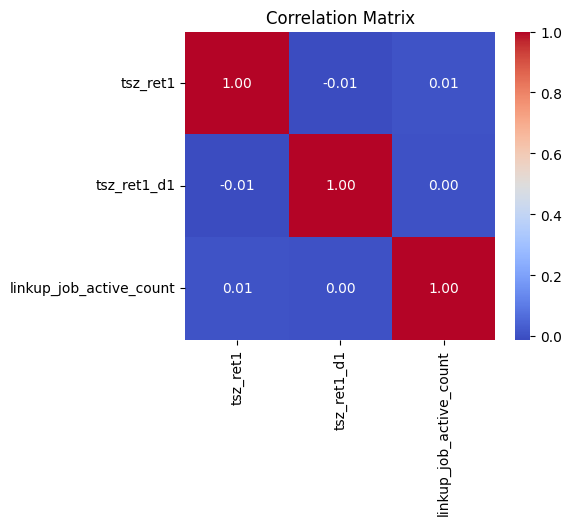

In [14]:
%matplotlib inline
plt.figure(figsize=(5, 4)) # adjust the figure size of the heatmap
correlation_matrix = df[features_ls].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('corr.png')

## **Training and validation**
- Training period: From 2006 to 2016 (11 years)
- Validation period: From 2017 to 2020 (4 years)

In [15]:
train_startdate = 20060101
train_enddate = 20161231

valid_startdate = 20170101
valid_enddate = 20201230

# split the df according to the periods of train/valid
train_mask = (df['dates'] >= train_startdate) & (df['dates'] <= train_enddate)
valid_mask = (df['dates'] >= valid_startdate) & (df['dates'] <= valid_enddate)

df_train = df[train_mask]
df_valid = df[valid_mask]
        
X_train,Y_train = df_train[features_ls].to_numpy(),df_train['target'].to_numpy()
X_valid,Y_valid = df_valid[features_ls].to_numpy(),df_valid['target'].to_numpy()

train_si,train_di = df_train['si'].values, df_train['di'].values
valid_si,valid_di = df_valid['si'].values, df_valid['di'].values

## **Model**

In [33]:
### ---- ---- ---- ---- Train your Model ---- ---- ---- ---- ###

from sklearn.ensemble import GradientBoostingRegressor

# train the model
regressor = GradientBoostingRegressor(n_estimators=400, learning_rate=0.1, max_depth=1, random_state=42)
regressor.fit(X_train, Y_train)

# predict
YPRED_train = regressor.predict(X_train)
YPRED_valid = regressor.predict(X_valid)

# alpha
alpha = np.full_like(data['ret1'], np.nan, dtype='float32', order='F')
alpha[train_si, train_di] = YPRED_train
alpha[valid_si, valid_di] = YPRED_valid

# accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
acc_train = accuracy_score(Y_train>=0, YPRED_train>=0)
acc_valid = accuracy_score(Y_valid>=0, YPRED_valid>=0)
print(f'Accuracy Train: {acc_train :>.3%}')
print(f'Accuracy Valid: {acc_valid :>.3%}')

Accuracy Train: 51.374%
Accuracy Valid: 51.371%


## **Simulation**

##### Post Processing (PP) function
- PP function applies the final risk-management constraints on the signal and makes our signal tradeable in real markets
- PP function reduces the turnover and increases the liquidity which reduces the slippage costs

In [78]:
# PP function - No need to modify the code below

def post_processing(data, preA, booksize):
    lookback = 252
    
    apply_locates = data['apply_locates']
    preA1 = np.copy(preA)
    preA1 *= data['valids']
  
    postA = op.at_nan2zero(preA1)
    postA = op.ts_mean_exp(op.at_nan2zero(postA), 10, 2/10)
    
    postA = op.cs_poslimit(postA, 0.1)
    postA = op.cs_indneut(postA, data['sector'])
    postA = op.cs_shrink_balance(postA)                                            

    long_scaler = op.ts_max(np.nansum(postA*(postA>0),axis=0),lookback)            
    short_scaler = op.ts_max(np.nansum(np.abs(postA)*(postA<0),axis=0),lookback)   
    scaler = np.maximum(long_scaler,short_scaler)                                  
    postA = postA/scaler * booksize                                                
    
    postA = op.op_vmcont(postA, data['valids'], data['close'], data['vol20'],
                         maxtrd=0.05*(booksize/1e9), maxpos=0.5*(booksize/1e9))
    postA = op.tc_hump(postA, data['close'], hump_factor=1.0)                      
    postA = op.cs_shrink_balance(postA)                                            

    long_scaler = op.ts_max(np.nansum(postA*(postA>0),axis=0),lookback)
    short_scaler = op.ts_max(np.nansum(np.abs(postA)*(postA<0),axis=0),lookback)
    scaler = np.maximum(long_scaler,short_scaler)
    postA = postA/scaler * booksize

    postA = op.cs_poslimit(postA, 0.1)
    postA = op.cs_shrink_balance(postA)                                            
    postA = apply_locates(postA, data, data['locate_utilization_rate'], data['max_rebate_rate'])
    return postA

In [79]:
postA = post_processing(data,alpha,data['booksize'])

In [80]:
mask = data['top1000'][:,3000]

In [81]:
maskss = (pd.DataFrame(alpha[mask,:][:, 3100]).isnull()==False).values

In [82]:
pd.DataFrame(alpha[mask,:][:, 3097:3105]).iloc[maskss,:]

,0,1,2,3,4,5,6,7
40,NaN,NaN,NaN,-0.000889,NaN,NaN,NaN,NaN
169,NaN,NaN,NaN,-0.003594,NaN,NaN,NaN,NaN
215,NaN,NaN,NaN,0.005644,NaN,NaN,NaN,NaN
222,NaN,NaN,NaN,0.002277,NaN,NaN,NaN,NaN
225,NaN,NaN,NaN,0.001855,NaN,NaN,NaN,NaN
372,NaN,NaN,NaN,0.003249,NaN,NaN,NaN,NaN
392,NaN,NaN,NaN,0.005499,NaN,NaN,NaN,NaN
406,NaN,NaN,NaN,0.000125,NaN,NaN,NaN,NaN
479,NaN,NaN,NaN,0.003376,NaN,NaN,NaN,NaN
507,NaN,NaN,NaN,-0.001541,NaN,NaN,NaN,NaN


In [84]:
pd.DataFrame(postA[mask,:][:, 3097:3115]).iloc[maskss,:]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
40,-102.120995,-114.749023,-110.492195,-2099.080811,-2029.569092,-1875.554688,-1773.598633,-1720.990112,-1436.231445,-1308.907837,-1146.239136,-1163.001587,-1182.559937,-351.320068,-312.478149,-295.044464,-297.754120,-264.525177
169,-90.911629,-98.667305,-95.659027,-5284.770996,-5002.611816,-4295.505371,-3544.801025,-3323.709473,-2812.411865,-2416.666260,-2254.187744,-2025.416870,-1779.883057,-351.320068,-312.478149,-295.044464,-293.993011,-264.525177
215,101.904114,99.542694,98.452797,1139.850342,2743.693848,3790.331543,3603.385986,2859.379395,2314.763428,1947.566650,1762.003662,1474.169189,1367.548340,379.371918,347.465332,331.420380,335.359406,316.545898
222,111.555130,111.719002,113.084518,2109.289795,1716.715210,1033.835571,1039.052124,427.091797,284.660095,283.321899,287.018616,301.200012,301.434204,303.820312,305.107880,303.585388,303.165314,305.572266
225,-98.399567,-107.180885,-103.952003,2802.232422,2376.104004,1196.390015,795.627441,400.086517,305.282166,113.394371,-103.333214,-246.090271,-256.061249,-260.540283,-251.177017,-249.766327,-244.240112,-231.401215
372,-96.875130,-105.623100,-104.658546,2583.883789,2543.868408,2098.306885,2074.506592,1334.202881,1055.082764,887.094055,457.919525,436.391052,343.991821,345.750214,347.465332,331.420380,338.057312,316.545898
392,-48.202679,-52.287102,-50.306496,2818.725342,4506.222168,3961.177734,3168.627441,2444.162598,1959.730835,1743.330688,1569.291870,1270.223389,980.737122,379.371918,347.465332,331.420380,332.122772,316.545898
406,-100.495659,-110.382195,-107.341095,-550.717651,-625.211548,-609.453735,-643.637207,-641.443604,-661.691589,-676.182495,-634.298828,-659.059143,-684.741943,-351.320068,-312.478149,-295.044464,-289.979584,-264.525177
479,-94.475250,-101.972206,-100.467430,3305.370117,3111.810547,2348.663574,1918.163208,1511.201904,1207.669556,1061.892822,1053.463257,889.265930,893.760498,379.371918,347.465332,331.420380,331.035522,316.545898
507,-100.999474,-108.641312,-104.968864,-2638.608643,-2588.546387,-2515.976074,-2109.047363,-2104.839355,-1872.664795,-1644.815308,-1544.533081,-1547.392334,-1390.603149,-351.320068,-312.478149,-295.044464,-291.017578,-264.525177


In [30]:
pd.DataFrame(postA[mask,:][:, 3000:3500])

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,-116.084801,-109.602257,-115.795387,-118.477554,-118.212425,-111.758926,-100.838402,-89.238365,-83.977867,-81.703903,...,62.744923,62.419086,63.639439,63.379204,64.476372,63.850853,63.671951,64.338783,6632.944824,5071.316895
1,-116.084801,-109.602257,-116.083321,-119.328354,-119.811348,-111.758926,-100.838402,-89.238365,-83.977867,-81.703903,...,-91.339005,-92.760284,-92.056374,-85.204964,-91.216301,-94.042366,-92.441841,-94.258606,-105.271317,-113.194084
2,164.967056,155.315399,151.030121,145.580185,145.744431,149.775208,139.411346,131.892441,123.837051,115.074646,...,2198.455322,993.474609,583.484558,293.890137,270.897766,256.784271,248.077423,224.942520,226.766373,223.831192
3,164.967056,155.315399,155.169067,154.592773,154.876328,149.775208,139.411346,131.892441,123.837051,115.074646,...,463.888672,401.209778,322.561127,293.890137,270.897766,256.784271,248.077423,224.942520,228.886627,227.099335
4,164.967056,155.315399,153.444107,154.832458,155.798248,149.775208,139.411346,131.892441,123.837051,115.074646,...,-390.107941,-331.511475,-264.051239,-225.355957,-222.039139,-219.324707,-211.512177,-193.679031,-217.997208,-225.208588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,0.000000,0.000000,0.000000,0.000000,2358.464355,2817.598145,1728.530884,1967.454590,2019.040405,115.074646,...,61.088341,61.520004,63.105412,63.897827,64.329430,67.643814,65.914894,68.003998,69.156624,70.309235
1251,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-346.567108,-331.511475,-264.051239,-225.355957,-222.039139,-219.324707,-211.512177,-193.679031,-214.487091,-220.538422
1252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-390.107941,-331.511475,-264.051239,-225.355957,-222.039139,-219.324707,-211.512177,-193.679031,-218.476166,-225.431976
1253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


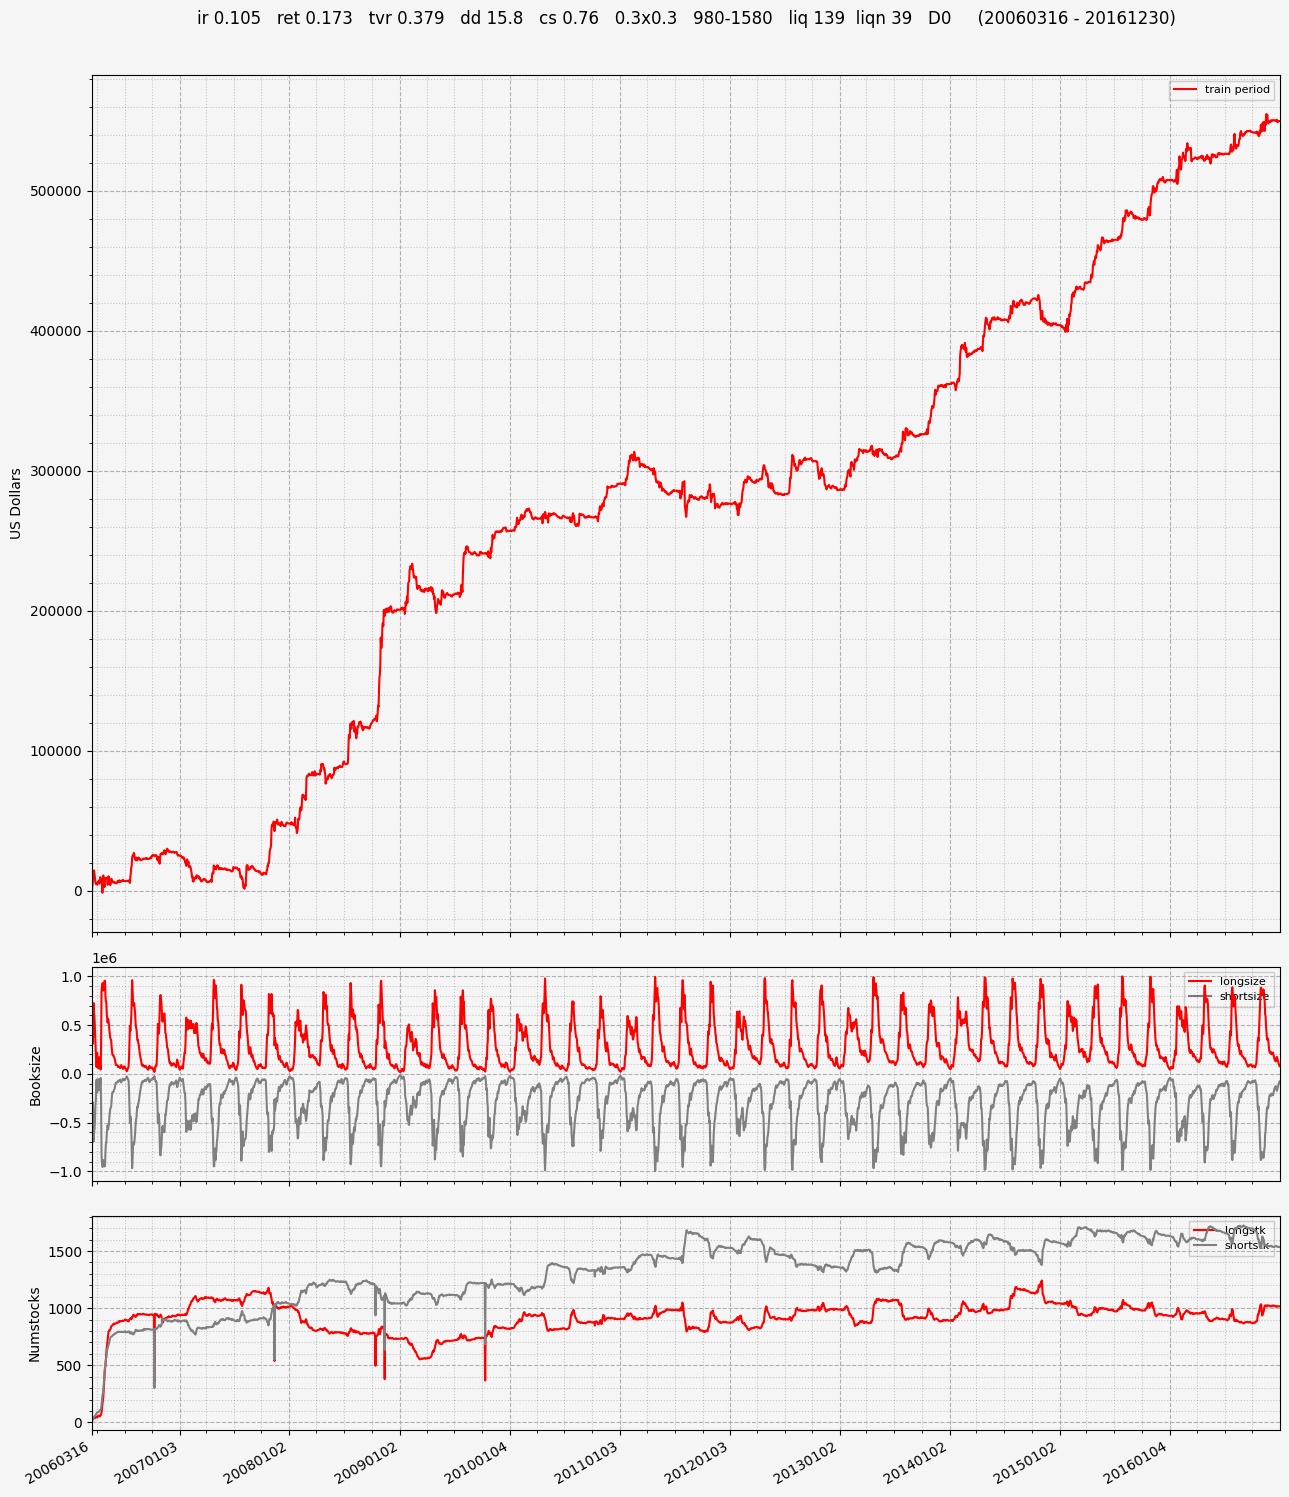

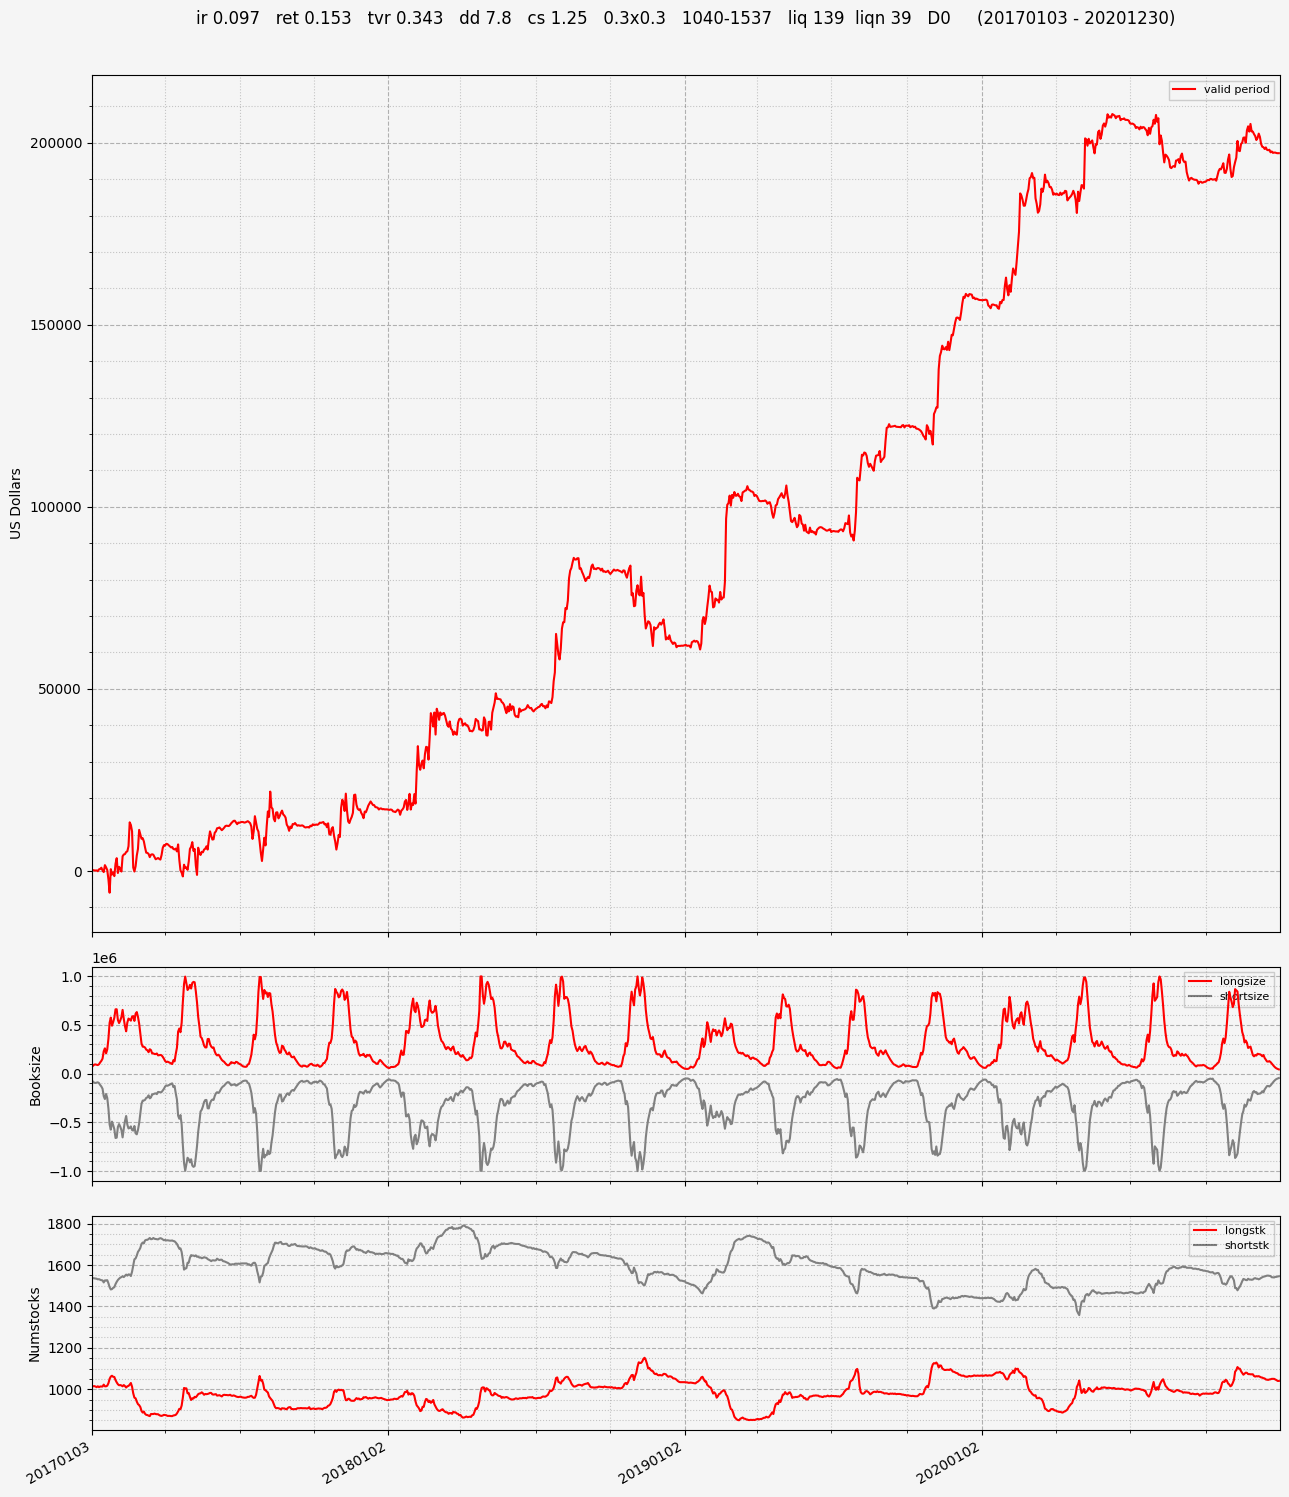

In [38]:
### ---- ---- ---- ---- No need to modify the code below ---- ---- ---- ---- ###
# simulation
postA = post_processing(data,alpha,data['booksize'])
postA[:, np.where(data['dates']>valid_enddate)[0][0]:]=np.nan # nan out values after valid_enddate
simres = op.op_simulate(data,postA,0,liq_on_valid_days=True,calc_liqn=True,slippage=True, slippage_model='fraction_spread', fraction_spread=0.2)

# simulation results
simres_train = op.cut_simres(simres,startdate=train_startdate,enddate=train_enddate)
simres_valid = op.cut_simres(simres,startdate=valid_startdate,enddate=valid_enddate)

# pnl plots
%matplotlib inline
op.op_plot(op.cut_simres(simres,startdate=train_startdate,enddate=train_enddate),label='train period')
op.op_plot(op.cut_simres(simres,startdate=valid_startdate,enddate=valid_enddate),label='valid period')

## **Summary**

In [39]:
# Summary on the Metrics
metrics = ['ir','ret','tvr','dd','liqn']
metrics_train = [acc_train*100]+[simres_train[mtc][-1] if isinstance(simres_train[mtc], np.ndarray) else simres_train[mtc] for mtc in metrics]
metrics_valid = [acc_valid*100]+[simres_valid[mtc][-1] if isinstance(simres_valid[mtc], np.ndarray) else simres_valid[mtc] for mtc in metrics]

pd.options.display.float_format = '{:.3f}'.format
simres_df = pd.DataFrame({"train":metrics_train,"valid":metrics_valid}, index=['accuracy']+metrics)
display(simres_df.T)

,accuracy,ir,ret,tvr,dd,liqn
train,51.444,0.105,0.173,0.379,15.775,38.941
valid,51.360,0.097,0.153,0.343,7.774,38.941


In [1]:
print(['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count', 'coverageret5ealready'])

['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count', 'coverageret5ealready']


In [40]:
# name of all features
features_ls = [col for col in df.columns if col not in ['target', 'si', 'di', 'dates']]
print(f"Current features: {features_ls}")

Current features: ['tsz_ret1', 'tsz_ret1_d1', 'linkup_job_active_count', 'coverageret5e']


In [29]:
regressor.feature_importances_

array([0.37846184, 0.21650612, 0.27676822, 0.12826382])

In [1068]:
del df
import gc
gc.collect()

50788